In [1]:
import os
os.chdir('/Users/apple/Desktop/SCP_Projects/')
import sys
sys.path.append('/Users/apple/Desktop/SCP_Projects/code/scDIA')
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

# from harmony import harmonize
# import scvi

# set data and figure dir
data_dir = '/Volumes/SU700/scpMS_data/scpMS_microglia/scpMS/'
fig_dir = 'SCP_Microglia/figures/1_4_batch_correction/'
results_dir = 'SCP_Microglia/results/1_4_batch_correction/'

if not os.path.exists(fig_dir):
    os.makedirs(fig_dir)
if not os.path.exists(results_dir):
    os.makedirs(results_dir)
    
sc.settings.verbosity = 3

In [2]:
def apply_publication_style(font_size=12, axes_linewidth=1.0):
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial'],
        'svg.fonttype': 'none',
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'font.size': font_size,
        'axes.titlesize': font_size + 1,
        'axes.labelsize': font_size,
        'xtick.labelsize': font_size,
        'ytick.labelsize': font_size,
        'legend.fontsize': font_size,
        'legend.frameon': False,
        'figure.dpi': 150,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'savefig.transparent': False,
    })
    sns.set_theme(context='paper', style='ticks', rc={
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans'],
        'axes.linewidth': axes_linewidth,
        'legend.frameon': False,
    })

apply_publication_style()

In [2]:
adata_maxlfq = sc.read_h5ad('SCP_Microglia/results/1_3_preprocessing/scp_MG_1c_maxlfq_gene_after_qc_remove_exo.h5ad')

In [4]:
# Gobal configs
n_hvgs = 2000
n_pcs = 20
n_neighbors = 20
batch_key = 'prepare_date'

In [4]:
sc.tl.pca(adata_maxlfq, n_comps=n_pcs, svd_solver='arpack', use_highly_variable=True)

sc.pp.neighbors(adata_maxlfq, n_neighbors=n_neighbors, n_pcs=n_pcs)

sc.tl.umap(adata_maxlfq, min_dist=0.3, spread=1.0)    

computing PCA
    with n_comps=50
    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:07)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:05)


In [4]:
%load_ext rpy2.ipython

In [6]:
%%R
suppressMessages({
    library(anndataR)
    library(qs2)
    library(Seurat)
})

seurat_obj <- read_h5ad("SCP_Microglia/results/1_3_preprocessing/scp_MG_1c_maxlfq_gene_after_qc_remove_exo_toR.h5ad", as = "Seurat")
qs2::qs_save(seurat_obj, "SCP_Microglia/results/1_4_batch_correction/scp_MG_1c_maxlfq_gene_after_qc_remove_exo.qs2")

In [5]:
print(adata_maxlfq)

AnnData object with n_obs × n_vars = 3068 × 3979
    obs: 'loading_date', 'prepare_date', 'column_id', 'LC_gradient', 'celltype', 'age', 'gender', 'brain_region', 'mass', 'plate_number', 'plate_location', 'Precursors_identified', 'Peptides_identified', 'ProteinGroups_identified', 'n_genes_detected', 'total_intensity', 'log2_total_intensity', 'pct_missing', 'pass_qc_filter'
    var: 'n_cells', 'n_cells_detected', 'pct_detected_cells', 'mean_intensity', 'median_intensity', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'X_normalize', 'age_colors', 'brain_region_colors', 'column_id_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'prepare_date_colors', 'scdia', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'log2_total_normalized', 'log2_total_normalized_fc_nan', 'raw_matrix'
    obsp: 'connectivities', 'distances'


In [6]:
adata_maxlfq_batch_corrected = adata_maxlfq.copy()

#### Harmony

In [7]:
adata_maxlfq_batch_corrected.obsm['Harmony'] = harmonize(
    adata_maxlfq_batch_corrected.obsm['X_pca'][:, :n_pcs],
    batch_mat=adata_maxlfq_batch_corrected.obs,
    batch_key=batch_key,
    max_iter_harmony=20,
)

	Initialization is completed.
	Completed 1 / 20 iteration(s).
	Completed 2 / 20 iteration(s).
	Completed 3 / 20 iteration(s).
	Completed 4 / 20 iteration(s).
	Completed 5 / 20 iteration(s).
	Completed 6 / 20 iteration(s).
	Completed 7 / 20 iteration(s).
	Completed 8 / 20 iteration(s).
	Completed 9 / 20 iteration(s).
	Completed 10 / 20 iteration(s).
	Completed 11 / 20 iteration(s).
	Completed 12 / 20 iteration(s).
	Completed 13 / 20 iteration(s).
	Completed 14 / 20 iteration(s).
	Completed 15 / 20 iteration(s).
Reach convergence after 15 iteration(s).


#### BBKNN

In [8]:
adata_maxlfq_bbknn = adata_maxlfq.copy()

# An important parameter for BBKNN is the number of neighbors per batch. 
# A suggested heuristic for this is to use 25 if there are more than 100,000 cells or the default of 3 if there are fewer than 100,000.
# == from sc best practises ==
sc.external.pp.bbknn(
    adata_maxlfq_bbknn,
    batch_key=batch_key,
    use_rep='X_pca',
    n_pcs=n_pcs,
    copy=False,
    neighbors_within_batch=3
)

adata_maxlfq_batch_corrected.uns['bbknn'] = adata_maxlfq_bbknn.uns['neighbors']
adata_maxlfq_batch_corrected.obsp['bbknn_connectivities'] = adata_maxlfq_bbknn.obsp['connectivities']
adata_maxlfq_batch_corrected.obsp['bbknn_distances'] = adata_maxlfq_bbknn.obsp['distances']
# del adata_maxlfq_bbknn

computing batch balanced neighbors
	finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)


#### Combat

In [9]:
# Combat use log-normalized data
adata_maxlfq_combat = adata_maxlfq.copy()
adata_maxlfq_combat.X = adata_maxlfq_combat.layers['log2_total_normalized'].copy()

adata_maxlfq_combat = adata_maxlfq_combat[:, adata_maxlfq_combat.var['highly_variable']].copy()

sc.pp.combat(
    adata_maxlfq_combat,
    key=batch_key,
    inplace=True
)

sc.tl.pca(adata_maxlfq_combat, svd_solver='arpack', n_comps=n_pcs)

# save combat embeddings to the final object
adata_maxlfq_batch_corrected.obsm['Combat'] = adata_maxlfq_combat.obsm['X_pca']

del adata_maxlfq_combat

Standardizing Data across genes.

Found 6 batches

Found 0 numerical variables:
	

Fitting L/S model and finding priors

Finding parametric adjustments

Adjusting data

computing PCA
    with n_comps=50
    finished (0:00:00)


#### Scanorama

In [10]:
adata_maxlfq_scanorama = adata_maxlfq.copy()

sc.external.pp.scanorama_integrate(
    adata_maxlfq_scanorama,
    key=batch_key,
    basis='X_pca',
    adjusted_basis='X_scanorama',
    knn=n_neighbors
)

adata_maxlfq_batch_corrected.obsm['Scanorama'] = adata_maxlfq_scanorama.obsm['X_scanorama']

del adata_maxlfq_scanorama

[[0.         0.45851528 0.76153846 0.38715953 0.43761302 0.10671256]
 [0.         0.         0.46069869 0.71011673 0.34497817 0.16593886]
 [0.         0.         0.         0.72051282 0.32911392 0.21538462]
 [0.         0.         0.         0.         0.65099458 0.52447552]
 [0.         0.         0.         0.         0.         0.64737794]
 [0.         0.         0.         0.         0.         0.        ]]
Processing datasets 0815 <=> 0911
Processing datasets 0911 <=> 0913
Processing datasets 0822 <=> 0913
Processing datasets 0913 <=> 1015
Processing datasets 1015 <=> 1105
Processing datasets 0913 <=> 1105
Processing datasets 0822 <=> 0911
Processing datasets 0815 <=> 0822
Processing datasets 0815 <=> 1015
Processing datasets 0815 <=> 0913
Processing datasets 0822 <=> 1015
Processing datasets 0911 <=> 1015
Processing datasets 0911 <=> 1105
Processing datasets 0822 <=> 1105
Processing datasets 0815 <=> 1105


#### scVI
We will do a small benchmark on scVI distribution parameter choice (normal or nb)

In [11]:
from lightning.pytorch.loggers import TensorBoardLogger

# seet seed for reproducibility
scvi.settings.seed = 42

logger_scvi_normal = TensorBoardLogger(results_dir + 'logs', name='scvi_normal')
logger_scvi_nb = TensorBoardLogger(results_dir + 'logs', name='scvi_nb')

adata_maxlfq_scvi = adata_maxlfq.copy()

# exclude non-highly variable genes
adata_maxlfq_scvi = adata_maxlfq_scvi[:, adata_maxlfq_scvi.var['highly_variable']].copy()

Seed set to 42


##### Normal

In [12]:
scvi.model.SCVI.setup_anndata(
    adata_maxlfq_scvi,
    layer='log2_total_normalized',
    batch_key=batch_key
)

scvi_model_normal = scvi.model.SCVI(
    adata_maxlfq_scvi,
    n_latent=20,
    n_layers=1,
    gene_likelihood='normal',
    dispersion='gene'
)

scvi_model_normal.train(
    max_epochs=600,
    early_stopping=True,
    batch_size=1024,
    logger=logger_scvi_normal
)

scvi_model_normal.save(results_dir + 'scVI_scp_model_normal', overwrite=True)

Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA A40') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Epoch 600/600: 100%|██████████| 600/600 [00:41<00:00, 14.95it/s, v_num=2, train_loss=4.44e+3]

`Trainer.fit` stopped: `max_epochs=600` reached.


Epoch 600/600: 100%|██████████| 600/600 [00:41<00:00, 14.51it/s, v_num=2, train_loss=4.44e+3]


In [13]:
adata_maxlfq_batch_corrected.obsm['scVI_normal'] = scvi_model_normal.get_latent_representation()

##### NB

In [14]:
scvi.model.SCVI.setup_anndata(
    adata_maxlfq_scvi,
    layer='log2_total_normalized',
    batch_key=batch_key
)

scvi_model_nb = scvi.model.SCVI(
    adata_maxlfq_scvi,
    n_latent=20,
    n_layers=1,
    gene_likelihood='nb',
    dispersion='gene'
)

scvi_model_nb.train(
    max_epochs=600,
    early_stopping=True,
    batch_size=1024,
    logger=logger_scvi_nb
)

scvi_model_nb.save(results_dir + 'scVI_scp_model_nb', overwrite=True)

Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Epoch 600/600: 100%|██████████| 600/600 [00:41<00:00, 14.70it/s, v_num=2, train_loss=1.89e+3]

`Trainer.fit` stopped: `max_epochs=600` reached.


Epoch 600/600: 100%|██████████| 600/600 [00:41<00:00, 14.46it/s, v_num=2, train_loss=1.89e+3]


In [15]:
adata_maxlfq_batch_corrected.obsm['scVI_nb'] = scvi_model_nb.get_latent_representation()

In [ ]:
adata_maxlfq_batch_corrected.write_h5ad(results_dir + f'scp_MG_1c_maxlfq_scanpy_npcs_{n_pcs}_batch_corrected.h5ad', compression='gzip')

print('Batch correction completed and results saved.')

Batch correction completed and results saved.


In [3]:
adata_maxlfq_batch_corrected = sc.read_h5ad(results_dir + f'scp_MG_1c_maxlfq_scanpy_npcs_{n_pcs}_batch_corrected.h5ad')

In [4]:
adata_maxlfq_batch_corrected

AnnData object with n_obs × n_vars = 3068 × 3979
    obs: 'loading_date', 'prepare_date', 'column_id', 'LC_gradient', 'celltype', 'age', 'gender', 'brain_region', 'mass', 'plate_number', 'plate_location', 'Precursors_identified', 'Peptides_identified', 'ProteinGroups_identified', 'n_genes_detected', 'total_intensity', 'log2_total_intensity', 'pct_missing', 'pass_qc_filter'
    var: 'n_cells', 'n_cells_detected', 'pct_detected_cells', 'mean_intensity', 'median_intensity', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'X_normalize', 'age_colors', 'bbknn', 'brain_region_colors', 'column_id_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'prepare_date_colors', 'scdia', 'umap'
    obsm: 'Combat', 'Harmony', 'Scanorama', 'X_pca', 'X_umap', 'scVI_nb', 'scVI_normal'
    varm: 'PCs'
    layers: 'log2_total_normalized', 'log2_total_normalized_fc_nan', 'raw_matrix'
    obsp: 'bbknn_connectivities', 'bbknn_distances', 'connectiv

In [6]:
adata_maxlfq_batch_corrected.obsm['X_pca'].shape

(3068, 20)

#### CCA

In [8]:
%load_ext rpy2.ipython

In [9]:
%%R -i n_hvgs -i n_pcs -o cca_embedding -i batch_key
# load packages
suppressMessages({
    library(Seurat)
    library(qs2)
    library(dplyr)
})

# cca integration
cca_object <- qs2::qs_read("SCP_Microglia/results/1_4_batch_correction/scp_MG_1c_maxlfq_gene_after_qc_remove_exo.qs2")
batch_vector <- cca_object@meta.data[[batch_key]]
names(batch_vector) <- rownames(cca_object@meta.data)
cca_object[['RNA']] <- split(cca_object[['RNA']], f = batch_vector)

cca_object <- cca_object %>%
    NormalizeData(verbose = FALSE) %>%
    FindVariableFeatures(nfeatures = n_hvgs, verbose = FALSE) %>%
    ScaleData(verbose = FALSE) %>%
    RunPCA(npcs = n_pcs, verbose = FALSE)
    
cca_object <- IntegrateLayers(
      object = cca_object, 
      method = CCAIntegration,
      orig.reduction = "pca", 
      new.reduction = "cca",
      verbose = FALSE
    )

cca_embedding <- cca_object@reductions$cca@cell.embeddings

  |                                                  | 0 % ~calculating   |++++                                              | 7 % ~19s           |+++++++                                           | 13% ~19s           |++++++++++                                        | 20% ~16s           |++++++++++++++                                    | 27% ~15s           |+++++++++++++++++                                 | 33% ~13s           |++++++++++++++++++++                              | 40% ~12s           |++++++++++++++++++++++++                          | 47% ~11s           |+++++++++++++++++++++++++++                       | 53% ~09s           |++++++++++++++++++++++++++++++                    | 60% ~08s           |++++++++++++++++++++++++++++++++++                | 67% ~07s           |+++++++++++++++++++++++++++++++++++++             | 73% ~05s           |++++++++++++++++++++++++++++++++++++++++          | 80% ~04s           |++++++++++++++++++++++++++++++++++++++++++++      | 87% ~03s 

In [10]:
adata_maxlfq_batch_corrected.obsm['CCA'] = cca_embedding

##### RPCA

In [11]:
%%R -i n_hvgs -i n_pcs -o rpca_embedding -i batch_key
rpca_object <- qs2::qs_read("SCP_Microglia/results/1_4_batch_correction/scp_MG_1c_maxlfq_gene_after_qc_remove_exo.qs2")
batch_vector <- rpca_object@meta.data[[batch_key]]
names(batch_vector) <- rownames(rpca_object@meta.data)
rpca_object[['RNA']] <- split(rpca_object[['RNA']], f = batch_vector)

rpca_object <- rpca_object %>%
    NormalizeData(verbose = FALSE) %>%
    FindVariableFeatures(nfeatures = n_hvgs, verbose = FALSE) %>%
    ScaleData(verbose = FALSE) %>%
    RunPCA(npcs = n_pcs, verbose = FALSE)
    
rpca_object <- IntegrateLayers(
      object = rpca_object, 
      method = RPCAIntegration,
      orig.reduction = "pca", 
      new.reduction = "rpca",
      verbose = FALSE
    )

rpca_embedding <- rpca_object@reductions$rpca@cell.embeddings

  |                                                  | 0 % ~calculating   |++++                                              | 7 % ~14s           |+++++++                                           | 13% ~12s           |++++++++++                                        | 20% ~11s           |++++++++++++++                                    | 27% ~10s           |+++++++++++++++++                                 | 33% ~10s           |++++++++++++++++++++                              | 40% ~09s           |++++++++++++++++++++++++                          | 47% ~08s           |+++++++++++++++++++++++++++                       | 53% ~07s           |++++++++++++++++++++++++++++++                    | 60% ~06s           |++++++++++++++++++++++++++++++++++                | 67% ~05s           |+++++++++++++++++++++++++++++++++++++             | 73% ~04s           |++++++++++++++++++++++++++++++++++++++++          | 80% ~03s           |++++++++++++++++++++++++++++++++++++++++++++      | 87% ~02s 

In [12]:
adata_maxlfq_batch_corrected.obsm['RPCA'] = rpca_embedding

#### FastMNN

In [13]:
%%R -i n_hvgs -i n_pcs -o fastmnn_embedding -i batch_key
suppressMessages({
    library(SeuratWrappers)
})

fastmnn_object <- qs2::qs_read("SCP_Microglia/results/1_4_batch_correction/scp_MG_1c_maxlfq_gene_after_qc_remove_exo.qs2")
batch_vector <- fastmnn_object@meta.data[[batch_key]]
names(batch_vector) <- rownames(fastmnn_object@meta.data)
fastmnn_object[['RNA']] <- split(fastmnn_object[['RNA']], f = batch_vector)

fastmnn_object <- fastmnn_object %>%
    NormalizeData(verbose = FALSE) %>%
    FindVariableFeatures(nfeatures = n_hvgs, verbose = FALSE) %>%
    ScaleData(verbose = FALSE) %>%
    RunPCA(npcs = n_pcs, verbose = FALSE)

fastmnn_object <- IntegrateLayers(
      object = fastmnn_object, 
      method = FastMNNIntegration,
      new.reduction = "fastmnn",
      verbose = FALSE
    )

fastmnn_embedding <- fastmnn_object@reductions$fastmnn@cell.embeddings

In [14]:
adata_maxlfq_batch_corrected.obsm['FastMNN'] = fastmnn_embedding

#### LIGER

In [15]:
liger_k = 20

In [16]:
%%R -i n_hvgs -i n_pcs -i liger_k -o liger_embedding -i batch_key
suppressMessages({
    library(Seurat)
    library(rliger)
    library(qs2)
    library(dplyr)
})

liger_object <- qs2::qs_read("SCP_Microglia/results/1_4_batch_correction/scp_MG_1c_maxlfq_gene_after_qc_remove_exo.qs2")
batch_vector <- liger_object@meta.data[[batch_key]]
names(batch_vector) <- rownames(liger_object@meta.data)
liger_object[['RNA']] <- split(liger_object[['RNA']], f = batch_vector)

liger_object <- liger_object %>%
    normalize() %>%
    selectGenes() %>%
    scaleNotCenter() %>%
    runINMF(k = liger_k) %>%
    quantileNorm()

liger_embedding <- liger_object@reductions$inmfNorm@cell.embeddings

ℹ Selecting variable features for dataset: "0815"
✔ ... 3313 features selected out of 3979 shared features
ℹ Selecting variable features for dataset: "0822"
✔ ... 2947 features selected out of 3979 shared features
ℹ Selecting variable features for dataset: "0911"
✔ ... 3333 features selected out of 3979 shared features
ℹ Selecting variable features for dataset: "0913"
✔ ... 3222 features selected out of 3979 shared features
ℹ Selecting variable features for dataset: "1015"
✔ ... 2946 features selected out of 3979 shared features
ℹ Selecting variable features for dataset: "1105"
✔ ... 3146 features selected out of 3979 shared features
✔ Finally 3979 shared variable features selected.


INMF started, niter=30
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
Total time:      6 sec
Objective error: 6.01031e+06


In [17]:
adata_maxlfq_batch_corrected.obsm['Liger'] = liger_embedding

In [14]:
adata_maxlfq_batch_corrected.obsm['scPROTEIN'] = np.load(results_dir + 'scprotein_embedding.npy')

from sklearn.decomposition import PCA
adata_maxlfq_batch_corrected.obsm['scPROTEIN_PCA'] = PCA(n_components=n_pcs).fit_transform(adata_maxlfq_batch_corrected.obsm['scPROTEIN'])

In [16]:
adata_maxlfq_batch_corrected.write_h5ad(results_dir + f'scp_MG_1c_maxlfq_npcs_{n_pcs}_batch_corrected.h5ad', compression='gzip')

In [17]:
for obsm_key in adata_maxlfq_batch_corrected.obsm.keys():
    print(f"adata_maxlfq_batch_corrected.obsm[{obsm_key}].shape: {adata_maxlfq_batch_corrected.obsm[obsm_key].shape}")

adata_maxlfq_batch_corrected.obsm[CCA].shape: (3068, 20)
adata_maxlfq_batch_corrected.obsm[Combat].shape: (3068, 20)
adata_maxlfq_batch_corrected.obsm[FastMNN].shape: (3068, 50)
adata_maxlfq_batch_corrected.obsm[Harmony].shape: (3068, 20)
adata_maxlfq_batch_corrected.obsm[Liger].shape: (3068, 20)
adata_maxlfq_batch_corrected.obsm[RPCA].shape: (3068, 20)
adata_maxlfq_batch_corrected.obsm[Scanorama].shape: (3068, 20)
adata_maxlfq_batch_corrected.obsm[X_pca].shape: (3068, 20)
adata_maxlfq_batch_corrected.obsm[X_umap].shape: (3068, 2)
adata_maxlfq_batch_corrected.obsm[scVI_nb].shape: (3068, 20)
adata_maxlfq_batch_corrected.obsm[scVI_normal].shape: (3068, 20)
adata_maxlfq_batch_corrected.obsm[scPROTEIN].shape: (3068, 400)
adata_maxlfq_batch_corrected.obsm[scPROTEIN_PCA].shape: (3068, 20)


In [5]:
adata_maxlfq_batch_corrected = sc.read_h5ad(results_dir + f'scp_MG_1c_maxlfq_npcs_{n_pcs}_batch_corrected.h5ad')

In [6]:
sc.pp.neighbors(adata_maxlfq_batch_corrected, n_neighbors=20)

sc.tl.umap(adata_maxlfq_batch_corrected, min_dist=0.3)

sc.tl.leiden(adata_maxlfq_batch_corrected, resolution=1.0, key_added='leiden_1.0')

computing neighbors
    using 'X_pca' with n_pcs = 20
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:02)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:02)
running Leiden clustering
    finished: found 19 clusters and added
    'leiden_1.0', the cluster labels (adata.obs, categorical) (0:00:00)


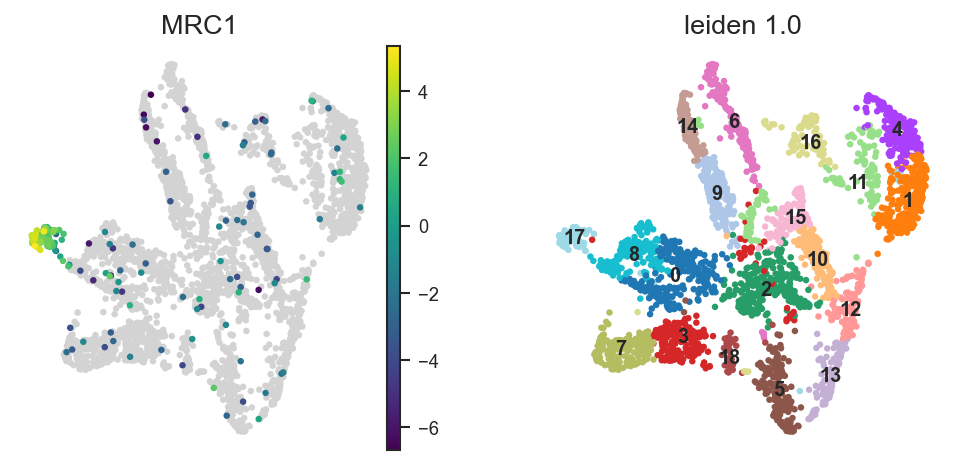

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))

for i, metric in enumerate(['Mrc1', 'leiden_1.0']):
    sc.pl.umap(
        adata_maxlfq_batch_corrected,
        color=metric,
        layer='log2_total_normalized_fc_nan',
        legend_loc='on data',
        frameon=False,
        ax=axes[i],
        show=False,
        title=None,
        cmap='viridis' if metric == 'Mrc1' else None
    )
    axes[i].set_title(' '.join(metric.split('_')).upper() if metric == 'Mrc1' else ' '.join(metric.split('_')), fontsize=13)

plt.subplots_adjust(wspace=0.3)

plt.savefig(fig_dir + 'leiden_for_BAM_clusters.pdf', dpi=300, bbox_inches='tight')

In [8]:
adata_maxlfq_batch_corrected.obs['celltype'] = adata_maxlfq_batch_corrected.obs['celltype'].cat.add_categories('BAM')
adata_maxlfq_batch_corrected.obs['celltype'][adata_maxlfq_batch_corrected.obs['leiden_1.0'] == '17'] = 'BAM'

adata_maxlfq_batch_corrected.obs['celltype'].value_counts()

celltype
MG     2974
BAM      94
Name: count, dtype: int64

In [9]:
# only get first n_pcs components for benchmark
for obsm_key in adata_maxlfq_batch_corrected.obsm.keys():
    adata_maxlfq_batch_corrected.obsm[obsm_key] = adata_maxlfq_batch_corrected.obsm[obsm_key][:, :n_pcs]

In [10]:
adata_maxlfq_batch_corrected.obs.celltype.value_counts()

celltype
MG     2974
BAM      94
Name: count, dtype: int64

In [11]:
from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection

In [12]:
bm_prepare_date = Benchmarker(
    adata_maxlfq_batch_corrected,
    batch_key="prepare_date",
    label_key="celltype",
    embedding_obsm_keys=["X_pca", "Harmony", "Scanorama", 'Combat',
                        'scVI_normal', 'scVI_nb', 'Liger', 'FastMNN', 'CCA', 'RPCA', 'scPROTEIN', 'scPROTEIN_PCA'],
    bio_conservation_metrics=BioConservation(
        isolated_labels=True,
        nmi_ari_cluster_labels_kmeans=False,
        nmi_ari_cluster_labels_leiden=False,
        silhouette_label=True,
        clisi_knn=False,
    ),
    batch_correction_metrics=BatchCorrection(
        bras=True,
        ilisi_knn=True,
        kbet_per_label=True,
        graph_connectivity=True,
        pcr_comparison=True,
    ),                      
    n_jobs=2,
)
bm_prepare_date.benchmark()

computing PCA
    with n_comps=50
    finished (0:00:00)


Embeddings: 100%|██████████| 12/12 [00:21<00:00,  1.79s/it]


In [13]:
bm_prepare_date.get_results(min_max_scale=False).to_csv(f"{results_dir}/benchmark_results_maxlfq_prepare_date.tsv", sep="\t")

<Figure size 1200x900 with 0 Axes>

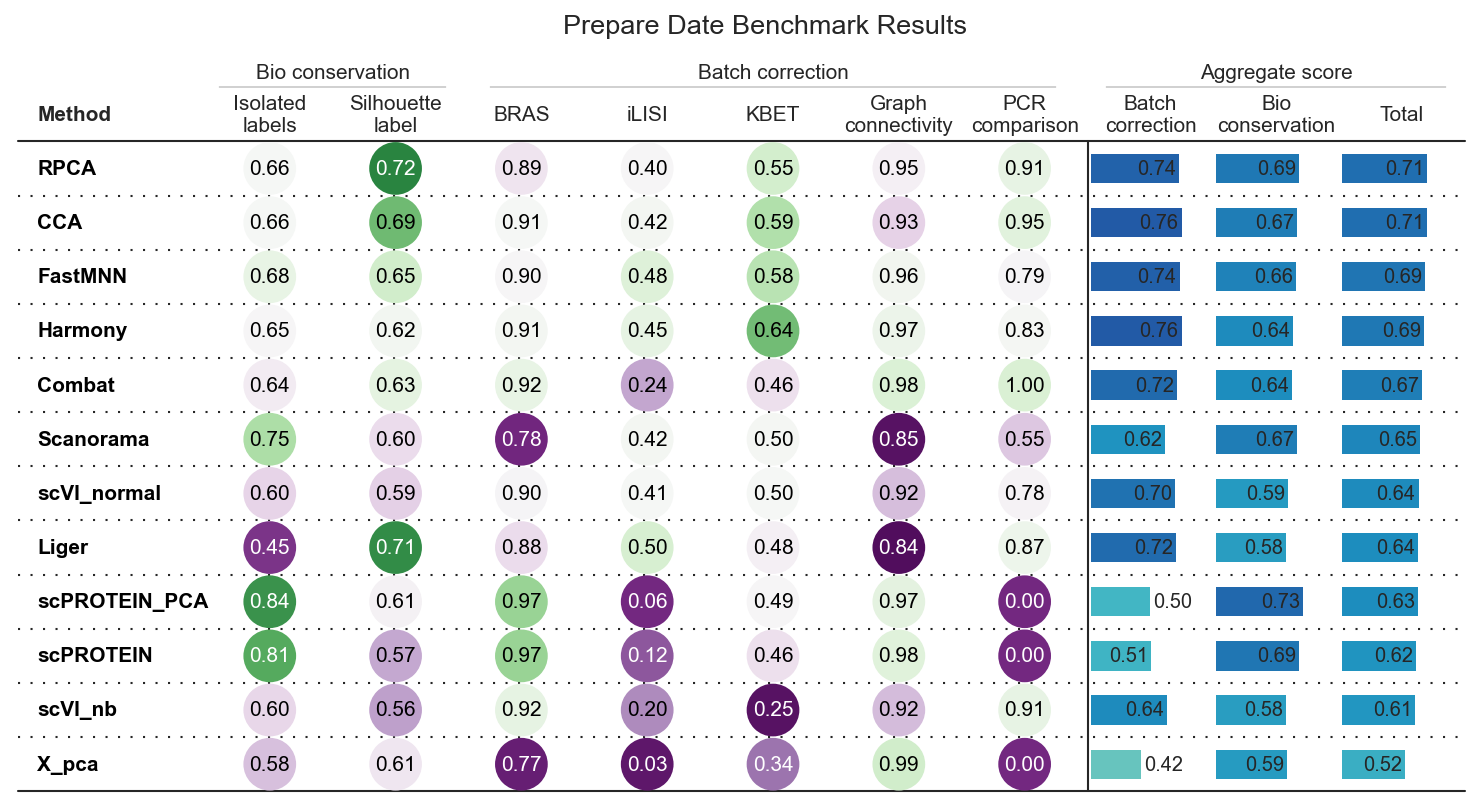

In [14]:
fig = plt.figure(figsize=(8, 6))
bm_prepare_date.plot_results_table(min_max_scale=False, show=False)
plt.text(-6.5, 23, 'Prepare Date Benchmark Results', fontsize=13)
plt.savefig(fig_dir + f'scib_npcs_{n_pcs}_prepare_date_comparison.pdf', dpi=300, bbox_inches='tight')

In [15]:
bm_column_id = Benchmarker(
    adata_maxlfq_batch_corrected,
    batch_key="column_id",
    label_key="celltype",
    embedding_obsm_keys=["X_pca", "Harmony", "Scanorama", 'Combat',
                        'scVI_normal', 'scVI_nb', 'Liger', 'FastMNN', 'CCA', 'RPCA', 'scPROTEIN', 'scPROTEIN_PCA'],
    bio_conservation_metrics=BioConservation(
        isolated_labels=True,
        nmi_ari_cluster_labels_kmeans=False,
        nmi_ari_cluster_labels_leiden=False,
        silhouette_label=True,
        clisi_knn=False,
    ),
    batch_correction_metrics=BatchCorrection(
        bras=True,
        ilisi_knn=True,
        kbet_per_label=True,
        graph_connectivity=True,
        pcr_comparison=True,
    ),
    n_jobs=2,
)
bm_column_id.benchmark()

computing PCA
    with n_comps=50
    finished (0:00:00)


Embeddings: 100%|██████████| 12/12 [00:20<00:00,  1.68s/it]


In [16]:
bm_column_id.get_results(min_max_scale=False).to_csv(f"{results_dir}/benchmark_results_maxlfq_column_id.tsv", sep="\t")

<Figure size 1200x900 with 0 Axes>

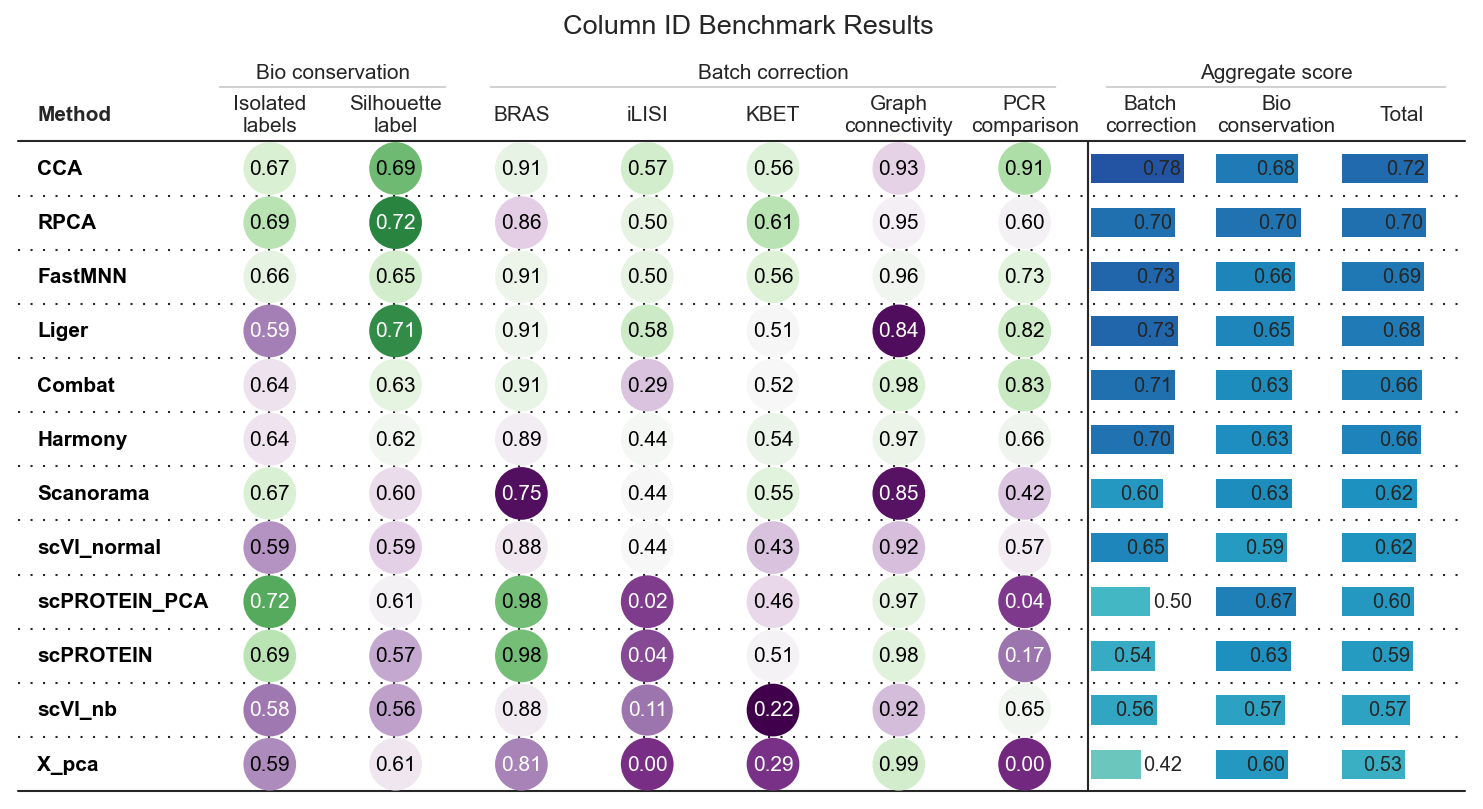

In [17]:
fig = plt.figure(figsize=(8, 6))
bm_column_id.plot_results_table(min_max_scale=False, show=False)

plt.text(-6.5, 23, 'Column ID Benchmark Results', fontsize=13)
plt.savefig(fig_dir + f'scib_npcs_{n_pcs}_column_id_comparison.pdf', dpi=300, bbox_inches='tight')

In [18]:
import scib
import anndata2ri
from rpy2.robjects import conversion, default_converter

# repair new anndata2ri versions that no longer have activate()/deactivate() functions
if not hasattr(anndata2ri, "activate") or not hasattr(anndata2ri, "deactivate"):
    _converter_backup = {"old": None}

    def _activate():
        _converter_backup["old"] = conversion.get_conversion()
        conversion.set_conversion(default_converter + anndata2ri.converter)

    def _deactivate():
        old = _converter_backup.get("old")
        if old is not None:
            conversion.set_conversion(old)
        else:
            conversion.set_conversion(default_converter)

    if not hasattr(anndata2ri, "activate"):
        anndata2ri.activate = _activate
    if not hasattr(anndata2ri, "deactivate"):
        anndata2ri.deactivate = _deactivate

In [19]:
adata_maxlfq_batch_corrected = sc.read_h5ad(results_dir + f'scp_MG_1c_maxlfq_npcs_{n_pcs}_batch_corrected.h5ad')

adata_maxlfq_batch_corrected_bbknn = adata_maxlfq_batch_corrected.copy()
adata_maxlfq_batch_corrected_bbknn.uns['neighbors'] = adata_maxlfq_batch_corrected_bbknn.uns['bbknn']
adata_maxlfq_batch_corrected_bbknn.obsp['connectivities'] = adata_maxlfq_batch_corrected_bbknn.obsp['bbknn_connectivities']
adata_maxlfq_batch_corrected_bbknn.obsp['distances'] = adata_maxlfq_batch_corrected_bbknn.obsp['bbknn_distances']

In [20]:
result_dict_kbet = {}

for method in ['CCA', 'RPCA', 'BBKNN']:
    for batch_key in ['prepare_date', 'column_id']:
        if method != 'BBKNN':
            result_dict_kbet[(method, batch_key)] = scib.me.kBET(
                adata_maxlfq_batch_corrected, 
                batch_key=batch_key, 
                label_key="celltype", 
                type_="embed", 
                embed=method
            )
        else:
            result_dict_kbet[(method, batch_key)] = scib.me.kBET(
                adata_maxlfq_batch_corrected_bbknn, 
                batch_key=batch_key, 
                label_key="celltype", 
                type_="knn"
            )

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
0 labels consist of a single batch or is too small. Skip.


/Users/apple/miniforge3/envs/scib_env/lib/python3.11/site-packages/scib/metrics/kbet.py:111: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = adata_tmp.obs.groupby(label_key).agg(


computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
0 labels consist of a single batch or is too small. Skip.


/Users/apple/miniforge3/envs/scib_env/lib/python3.11/site-packages/scib/metrics/kbet.py:111: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = adata_tmp.obs.groupby(label_key).agg(


computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
0 labels consist of a single batch or is too small. Skip.


...

/Users/apple/miniforge3/envs/scib_env/lib/python3.11/site-packages/scib/metrics/kbet.py:111: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = adata_tmp.obs.groupby(label_key).agg(


Adding diffusion to step 2
0 labels consist of a single batch or is too small. Skip.


/Users/apple/miniforge3/envs/scib_env/lib/python3.11/site-packages/scib/metrics/kbet.py:111: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = adata_tmp.obs.groupby(label_key).agg(


Adding diffusion to step 2
0 labels consist of a single batch or is too small. Skip.


/Users/apple/miniforge3/envs/scib_env/lib/python3.11/site-packages/scib/metrics/kbet.py:111: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = adata_tmp.obs.groupby(label_key).agg(


In [21]:
result_dict_ilisi = {}

for method in ['CCA', 'RPCA', 'BBKNN']:
    for batch_key in ['prepare_date', 'column_id']:
        if method != 'BBKNN':
            result_dict_ilisi[(method, batch_key)] = scib.me.ilisi_graph(
                adata_maxlfq_batch_corrected, 
                batch_key=batch_key, 
                type_="embed", 
                use_rep=method
            )
        else:
            result_dict_ilisi[(method, batch_key)] = scib.me.ilisi_graph(
                adata_maxlfq_batch_corrected_bbknn, 
                batch_key=batch_key, 
                type_="knn",
                use_rep=method
            )

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)


In [22]:
result_dict_kbet

{('CCA', 'prepare_date'): np.float64(0.22465798045602603),
 ('CCA', 'column_id'): np.float64(0.2967752442996743),
 ('RPCA', 'prepare_date'): np.float64(0.11882736156351792),
 ('RPCA', 'column_id'): np.float64(0.24501628664495112),
 ('BBKNN', 'prepare_date'): np.float64(0.21811074918566775),
 ('BBKNN', 'column_id'): np.float64(0.14485342019543967)}

In [23]:
result_dict_ilisi

{('CCA', 'prepare_date'): np.float64(0.5691457760113151),
 ('CCA', 'column_id'): np.float64(0.7014872797906344),
 ('RPCA', 'prepare_date'): np.float64(0.5414896348196464),
 ('RPCA', 'column_id'): np.float64(0.5851971232522468),
 ('BBKNN', 'prepare_date'): np.float64(0.5453195481994006),
 ('BBKNN', 'column_id'): np.float64(0.6767497090948769)}

In [24]:
result_df_kbet = pd.Series(result_dict_kbet).reset_index()
result_df_kbet.columns = ['Method', 'Batch_Key', 'kBET_score']

In [25]:
result_df_ilisi = pd.Series(result_dict_ilisi).reset_index()
result_df_ilisi.columns = ['Method', 'Batch_Key', 'iLISI_score']

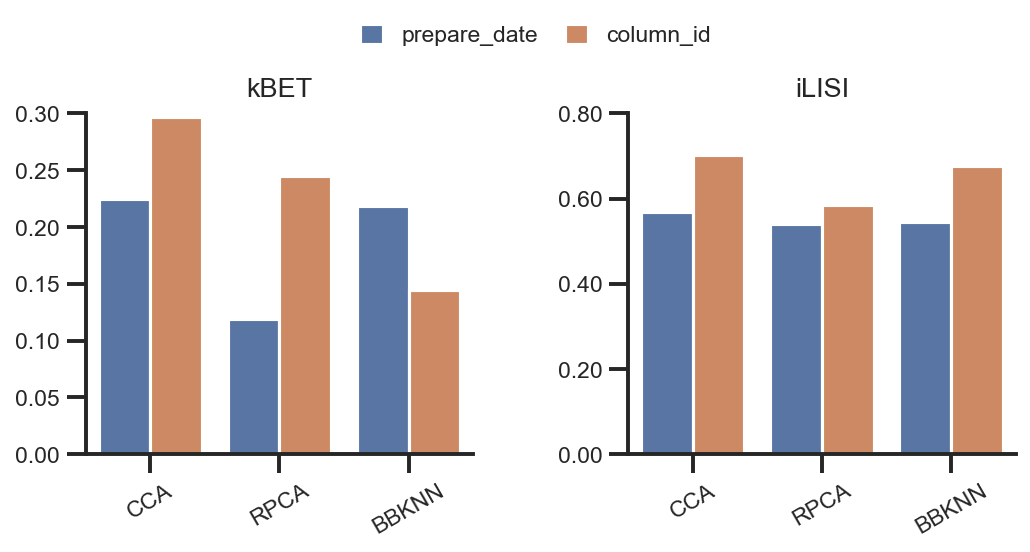

In [26]:
from matplotlib.ticker import FormatStrFormatter
fig, axes = plt.subplots(1, 2, figsize=(8, 3.2), sharex=False)

plot_info = [
    (result_df_kbet, "kBET_score", "kBET", (0, 0.3)),
    (result_df_ilisi, "iLISI_score", "iLISI", (0, 0.8)),
]

for ax, (df, y_col, title, ylim) in zip(axes, plot_info):
    sns.barplot(
        data=df,
        x="Method",
        y=y_col,
        hue="Batch_Key",
        ax=ax,
        dodge=0.35,
        errorbar=None,
    )

    ax.set_title(title, fontsize=13, pad=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_ylim(*ylim)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

    ax.tick_params(axis="x", labelsize=11, rotation=30)
    ax.tick_params(axis="y", labelsize=11)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if ax.get_legend() is not None:
        ax.get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.05),
    ncol=len(labels),
    frameon=False,
    fontsize=11,
    columnspacing=1.2,
    handlelength=1, handleheight=1,
)

plt.subplots_adjust(wspace=0.4, top=0.82)

plt.savefig(
    fig_dir + "kBET_ilisi_comparison_barplot.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


### Compare scVI_normal and scVI_nb

In [27]:
sc.pp.neighbors(adata_maxlfq_batch_corrected, use_rep='scVI_normal', n_neighbors=20)
sc.tl.umap(adata_maxlfq_batch_corrected, min_dist=0.3)
adata_maxlfq_batch_corrected.obsm['scVI_normal_umap'] = adata_maxlfq_batch_corrected.obsm['X_umap']

sc.pp.neighbors(adata_maxlfq_batch_corrected, use_rep='scVI_nb', n_neighbors=20)
sc.tl.umap(adata_maxlfq_batch_corrected, min_dist=0.3)
adata_maxlfq_batch_corrected.obsm['scVI_nb_umap'] = adata_maxlfq_batch_corrected.obsm['X_umap']

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:02)
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:02)


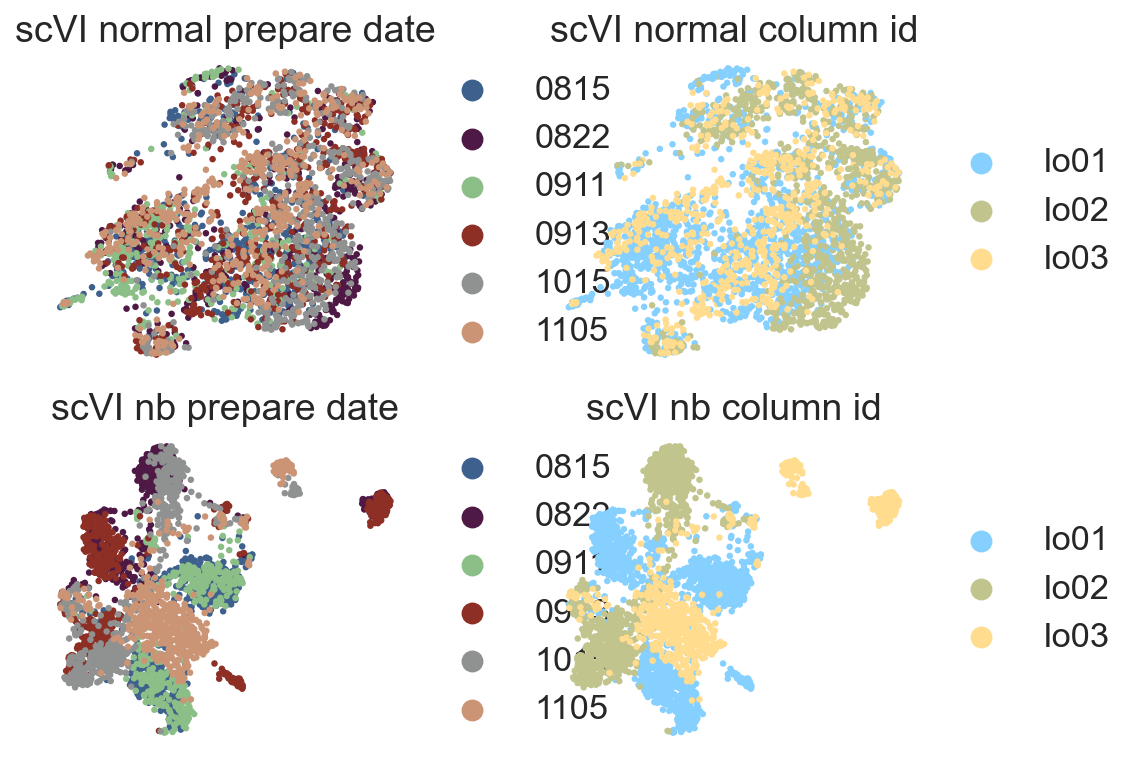

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(7.5, 6))
axes = axes.flatten()
i = 0
for embedding in ['scVI_normal_umap', 'scVI_nb_umap']:
    for key in ['prepare_date', 'column_id']:
        sc.pl.embedding(
            adata_maxlfq_batch_corrected,
            basis=embedding,
            color=key,
            show=False,
            frameon=False,
            ax=axes[i],
            title=' '.join(embedding.split('_')[:2]) + ' ' + ' '.join(key.split('_'))
        )
        i+=1
plt.subplots_adjust(wspace=0.4, hspace=0.2)
plt.savefig(fig_dir + 'scVI_normal_nb_comparison.pdf', dpi=300, bbox_inches='tight')